#**Libraries**

In [ ]:
# Install necessary libraries
!pip install deep-translator vaderSentiment

import pandas as pd
import numpy as np
import re
from deep_translator import GoogleTranslator
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.2 MB/s eta 0:00:00


#**Load Dataset**

In [ ]:
try:
    df = pd.read_csv('Shopee_Reviews.csv')
    print("✅ Data Loaded Successfully!")
except FileNotFoundError:
    print("❌ Error: 'Shopee_Reviews.csv' not found. Please upload it.")


✅ Data Loaded Successfully!


#**Data Wrangling**

In [ ]:
# Date format fixing
def clean_date(x):
    if pd.isna(x): return None
    x_str = str(x)
    try:
        if 'T' in x_str: return pd.to_datetime(x_str)
        else: return pd.to_datetime(x_str, dayfirst=True)
    except: return None

df['temp_date'] = pd.to_datetime(df['Date'].apply(clean_date), utc=True)
df['Date'] = df['temp_date'].dt.strftime('%d/%m/%Y')
if df['Date'].isnull().any():
    df['Date'].fillna(df['Date'].mode()[0], inplace=True)
df.drop(columns=['temp_date'], inplace=True)

df.head()

,Date,Rating,Review,User
0,01/02/2026,1,kedekut syiling emas bila digunakan untuk pemb...,Mohd Fariq
1,01/02/2026,5,I personally think that this is the best app I...,likchan622 likchan622
2,01/02/2026,5,terbaik,Hisham Sabdin
3,01/02/2026,5,Hope best services thanks,Raine WM
4,01/02/2026,5,ok,Aliff Syazwan


In [ ]:
#3. Remove Duplicates
df.drop_duplicates(inplace=True)

df.shape

(2793, 4)

In [ ]:
#2.Removing Missing Values
for col in df.select_dtypes(include=['number']).columns:
    df[col].fillna(df[col].mean(), inplace=True)
for col in df.select_dtypes(include=['object']).columns:
    if not df[col].mode().empty:
        df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()

/tmp/ipython-input-3280995471.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-3280995471.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,0
Date,0
Rating,0
Review,0
User,0


#**Transformation (Other Language to English)**

In [ ]:
# Translation (Preserving Emojis) ---
print("🔄 Starting Translation (This may take a few minutes)...")
translator = GoogleTranslator(source='auto', target='en')

# Regex to detect if a string contains only emojis
EMOJI_PATTERN = re.compile(
    "["  # Start character set
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+"
)

def translate_review(text):
    if not isinstance(text, str):
        return ""

    # Check if the text is composed ONLY of emojis
    if EMOJI_PATTERN.fullmatch(text.strip()):
        return text.strip() # Return original text if it's just emojis

    # Otherwise, proceed with translation
    try:
        return translator.translate(text)
    except:
        return text

df['Translated_Review'] = df['Review'].apply(translate_review)
print("✅ Translation Complete.")

df.head()

🔄 Starting Translation (This may take a few minutes)...
✅ Translation Complete.


,Date,Rating,Review,User,Translated_Review
0,01/02/2026,1,kedekut syiling emas bila digunakan untuk pemb...,Mohd Fariq,being stingy with gold coins when used to purc...
1,01/02/2026,5,I personally think that this is the best app I...,likchan622 likchan622,I personally think that this is the best app I...
2,01/02/2026,5,terbaik,Hisham Sabdin,the best
3,01/02/2026,5,Hope best services thanks,Raine WM,Hope best services thanks
4,01/02/2026,5,ok,Aliff Syazwan,ok


In [ ]:
# Save
output_file = 'Shopee_Reviews_Cleaned.csv'
df.to_csv(output_file, index=False)

#**Sentiment Analysis**

In [ ]:
try:
    df = pd.read_csv('Shopee_Reviews_Cleaned and Manually Labelled.csv')
    print("✅ Data Loaded Successfully!")
except FileNotFoundError:
    print("❌ Error: 'Shopee_Reviews_Cleaned and Manually Labelled.csv' not found. Please upload it.")

✅ Data Loaded Successfully!


In [ ]:
# Initialize VADER
analyzer = SentimentIntensityAnalyzer()


# Sentiment Analysis (3 Labels)
print("🔄 Running VADER Sentiment Analysis with 3 Labels...")

def get_sentiment_data(text):
    text = str(text)

    # 1. Run Standard VADER Analysis FIRST
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']

    # Define 3 Sentiment Categories based on Compound Score
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'

    return compound, label


# Apply function
df[['Sentiment_Score_Vader', 'Sentiment_Label_Vader']] = df['Translated_Review'].apply(
    lambda x: pd.Series(get_sentiment_data(x))
)

print("✅ VADER Sentiment Analysis Complete.")

🔄 Running VADER Sentiment Analysis with 3 Labels...
✅ VADER Sentiment Analysis Complete.


In [ ]:
df.head()

,Date,Rating,Review,User,Translated_Review,Manually_Labelled_Sentiment,Sentiment_Score_Vader,Sentiment_Label_Vader
0,1/2/2026,1,kedekut syiling emas bila digunakan untuk pemb...,Mohd Fariq,being stingy with gold coins when used to purc...,Negative,-0.1353,Negative
1,1/2/2026,5,I personally think that this is the best app I...,likchan622 likchan622,I personally think that this is the best app I...,Positive,0.9412,Positive
2,1/2/2026,5,terbaik,Hisham Sabdin,the best,Positive,0.6369,Positive
3,1/2/2026,5,Hope best services thanks,Raine WM,Hope best services thanks,Positive,0.8750,Positive
4,1/2/2026,5,ok,Aliff Syazwan,ok,Neutral,0.2960,Positive


In [ ]:
df.shape


(2793, 8)

#**Topic Segmentation**

In [ ]:
# Topic Modelling (6 Specific Topics)

# MANUAL TOPIC ASSIGNMENT
print("🔄 Running Topic Modelling (LDA) with 6 Topics...")
topic_keywords = {
    'Transaction & Refund Services': ['refund', 'money', 'pay', 'transaction', 'wallet', 'credit', 'payment', 'scam', 'transfer'],
    'Customer Support': ['support', 'service', 'agent', 'chat', 'reply', 'rude', 'staff', 'help', 'contact'],
    'Delivery Services': ['delivery', 'late', 'courier', 'driver', 'shipping', 'wait', 'slow', 'arrive', 'received'],
    'App Features & Livestream': ['live', 'stream', 'video', 'voucher', 'game', 'spin', 'prize', 'coin', 'interface', 'feature'],
    'Technical Features': ['bug', 'crash', 'lag', 'error', 'fix', 'update', 'install', 'open', 'close', 'screen'],
    'General Satisfaction': ['good', 'great', 'love', 'best', 'nice', 'excellent', 'bad', 'worst', 'terrible', 'hate', 'ok']
}


# Preprocessing for LDA (Remove numbers/punctuation but keep words)
def assign_topic_by_keyword(text):
    text = str(text).lower()

# Check each topic's keywords
    for topic, keywords in topic_keywords.items():
        if any(word in text for word in keywords):
            return topic

    # Default if no keyword matches (You can change this to 'General' or 'Uncategorized')
    return 'General Satisfaction'

print("🔄 Assigning Topics based on your keywords...")
df['Topic_Name'] = df['Translated_Review'].apply(assign_topic_by_keyword)

print("✅ Complete.")



🔄 Running Topic Modelling (LDA) with 6 Topics...
🔄 Assigning Topics based on your keywords...
✅ Complete.


In [ ]:
# Define the desired order for sentiment labels
sentiment_order_display = ['Positive', 'Neutral', 'Negative']

# Convert 'Sentiment_Label' to a categorical type with the specified order
df['Sentiment_Label_Vader'] = pd.Categorical(df['Sentiment_Label_Vader'], categories=sentiment_order_display, ordered=True)

# Actual numbers for report writing
display(Markdown("## **Number of Reviews per Sentiment**"))
print(df['Sentiment_Label_Vader'].value_counts().reindex(sentiment_order_display, fill_value=0))

display(Markdown("## **Percentage of Reviews per Sentiment**"))
print(df['Sentiment_Label_Vader'].value_counts(normalize=True).reindex(sentiment_order_display, fill_value=0) * 100)

display(Markdown("## **Percentage of Reviews per Topic**"))
print(df['Topic_Name'].value_counts(normalize=True) * 100)

## **Number of Reviews per Sentiment**

Sentiment_Label_Vader
Positive    1552
Neutral      292
Negative     949
Name: count, dtype: int64


## **Percentage of Reviews per Sentiment**

Sentiment_Label_Vader
Positive    55.567490
Neutral     10.454708
Negative    33.977802
Name: proportion, dtype: float64


## **Percentage of Reviews per Topic**

Topic_Name
General Satisfaction             47.977086
Transaction & Refund Services    22.341568
Customer Support                 12.602936
Delivery Services                 8.557107
App Features & Livestream         6.158253
Technical Features                2.363050
Name: proportion, dtype: float64


#**Visualisation for Non Labelled Sentiment**

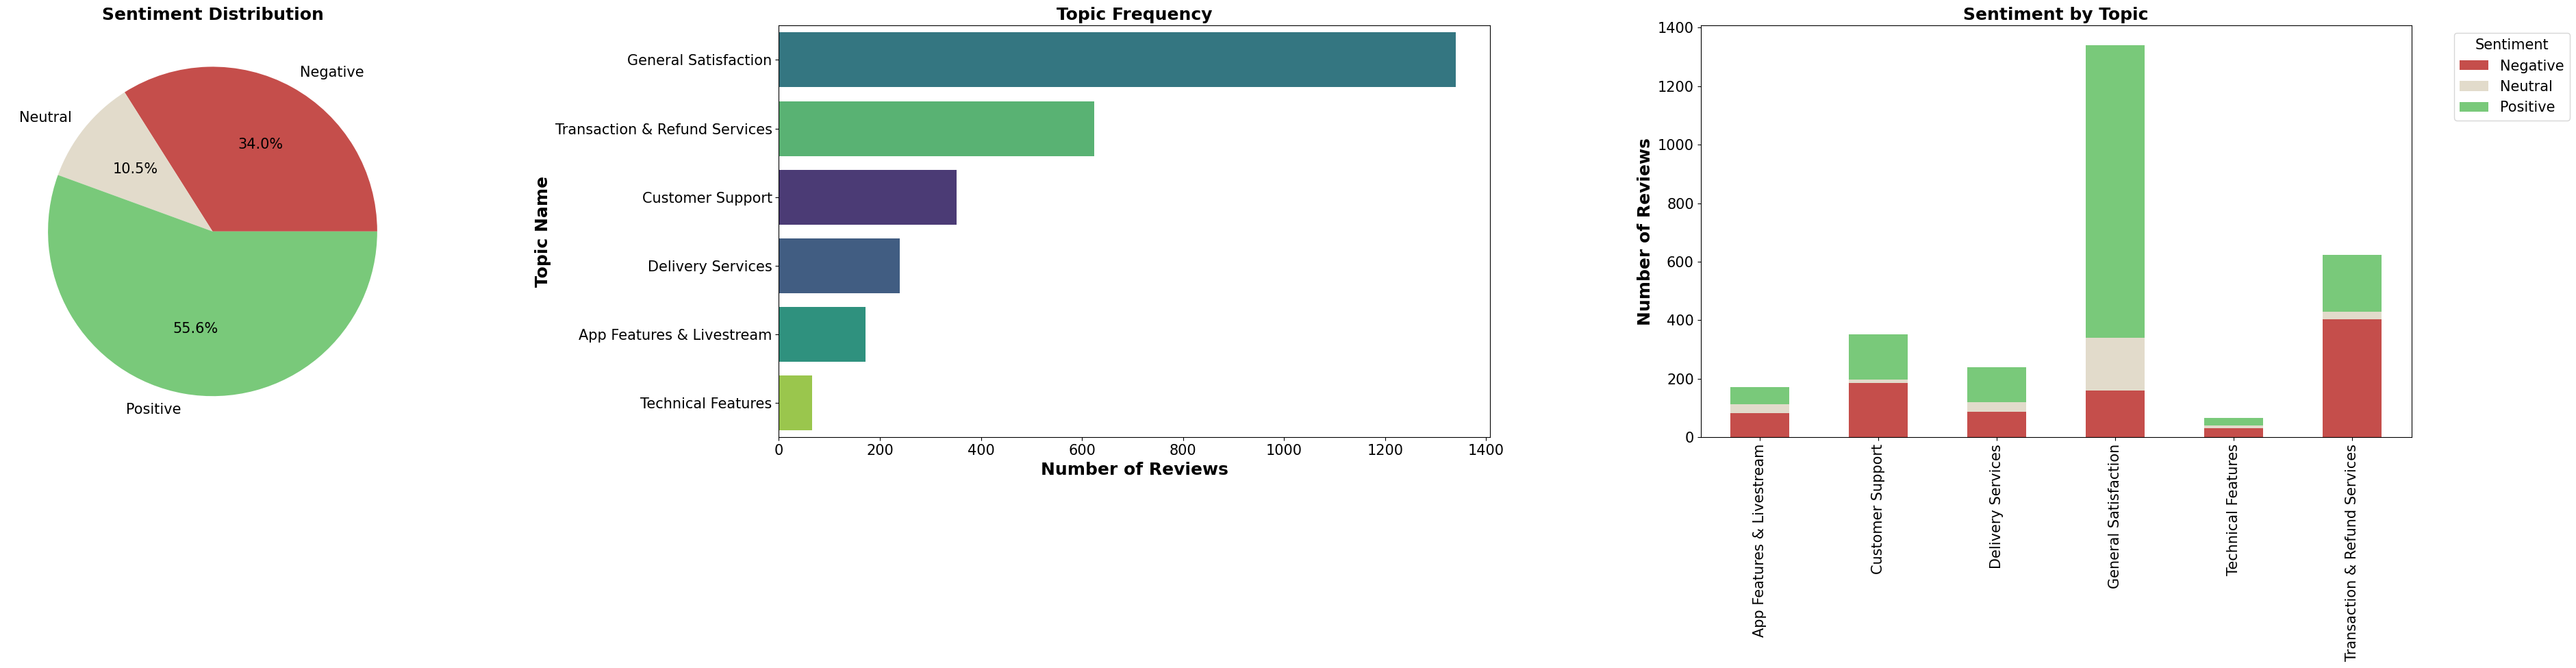

DETAILED BREAKDOWN
Sentiment_Label_Vader          Negative  Neutral  Positive
Topic_Name                                                
App Features & Livestream            82       30        60
Customer Support                    185       12       155
Delivery Services                    87       34       118
General Satisfaction                161      180       999
Technical Features                   31        9        26
Transaction & Refund Services       403       27       194


In [ ]:
# Define the specific colors
color_map = {
    'Positive':      '#79c97a',  # Green
    'Neutral':       '#e2dbcb',  # Beige
    'Negative':      '#c54e4b'   # Red
}

# Define the Chronological Order (Bottom to Top for Stacked Bar)
# We want Negative at bottom, Positive at top
sentiment_order = ['Negative', 'Neutral', 'Positive']

# Set global font size for better readability
plt.rcParams.update({'font.size': 15})

# --- Visualization ---
plt.figure(figsize=(40, 10)) # Control figure size




# A. Pie Chart
plt.subplot(1, 3, 1)
sent_counts = df['Sentiment_Label_Vader'].value_counts()
# Reorder counts to match our color list logic if needed, but dict mapping is safer
sent_counts = sent_counts.reindex(sentiment_order, fill_value=0) # Reindex to ensure desired order
plt.pie(sent_counts, labels=sent_counts.index, autopct='%1.1f%%',
        colors=[color_map[label] for label in sent_counts.index])
plt.title('Sentiment Distribution', fontsize=18, fontweight='bold')




# B. Bar Chart (Topics)
plt.subplot(1, 3, 2)
ax_b = sns.countplot(y='Topic_Name', data=df,
              order=df['Topic_Name'].value_counts().index,
              hue='Topic_Name', palette='viridis', legend=False) # Fixed FutureWarning
plt.title('Topic Frequency', fontsize=18, fontweight='bold')
plt.xlabel('Number of Reviews', fontsize=18, fontweight='bold')
ax_b.set_ylabel('Topic Name', fontsize=18, fontweight='bold')




# C. Stacked Bar Chart (Custom Colors & Order)
plt.subplot(1, 3, 3)

# Create Pivot Table
pivot_df = pd.crosstab(df['Topic_Name'], df['Sentiment_Label_Vader'])

# Reindex columns to force the specific order: Neg -> Neutral -> Pos
pivot_df = pivot_df.reindex(columns=sentiment_order, fill_value=0)

# Plot
# Note: In a stacked plot, the first column in the dataframe goes to the BOTTOM.
# So 'Negative' will be at the bottom, 'Positive' at the top.
ax_c = pivot_df.plot(kind='bar', stacked=True, ax=plt.gca(),
              color=[color_map[col] for col in pivot_df.columns])

plt.title('Sentiment by Topic', fontsize=18, fontweight='bold')
plt.xlabel('', fontsize=18)
ax_c.set_ylabel('Number of Reviews', fontsize=18, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Sentiment")

plt.tight_layout()
plt.show()

# Set display options to avoid wrapping for the pivot table output
pd.set_option('display.width', 1000) # Set a wide display width
pd.set_option('display.max_columns', None) # Show all columns

# Print the pivot table for your report
print("DETAILED BREAKDOWN")
print(pivot_df)

# Reset display options to default to avoid affecting subsequent outputs
pd.reset_option('display.width')
pd.reset_option('display.max_columns')

## **Model Accuracy and Deviation Analysis**

### Overall Accuracy of VADER Sentiment Model: **77.37%**

### Confusion Matrix (Manual vs. VADER)

,Predicted Negative,Predicted Neutral,Predicted Positive
True Negative,924,112,279
True Neutral,11,52,88
True Positive,14,128,1185


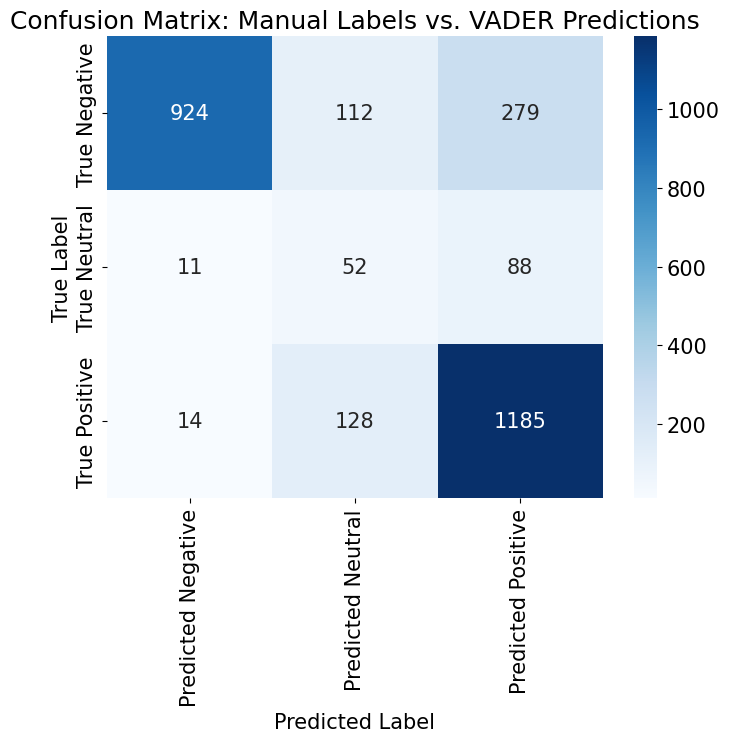

### Classification Report

,precision,recall,f1-score,support
Negative,0.973656,0.702662,0.816254,1315.00000
Neutral,0.178082,0.344371,0.234763,151.00000
Positive,0.763531,0.892992,0.823203,1327.00000
accuracy,0.773720,0.773720,0.773720,0.77372
macro avg,0.638423,0.646675,0.624740,2793.00000
weighted avg,0.830811,0.773720,0.788118,2793.00000


### Deviation from Manual Labels (Golden Set)

,Total Manual Labels,Correctly Predicted by VADER,Deviation (Misclassified),Deviation Percentage
Negative,1315,924,391,29.73%
Neutral,151,52,99,65.56%
Positive,1327,1185,142,10.70%


In [ ]:
# Ensure both columns are string type for consistent comparison
df['Manually_Labelled_Sentiment'] = df['Manually_Labelled_Sentiment'].astype(str)
df['Sentiment_Label_Vader'] = df['Sentiment_Label_Vader'].astype(str)

# Filter out any rows where manual label might be missing or not in expected categories (if any)
df_filtered = df[df['Manually_Labelled_Sentiment'].isin(['Positive', 'Neutral', 'Negative'])].copy()

y_true = df_filtered['Manually_Labelled_Sentiment']
y_pred = df_filtered['Sentiment_Label_Vader']

# 1. Calculate Accuracy
accuracy = accuracy_score(y_true, y_pred)
display(Markdown(f"### Overall Accuracy of VADER Sentiment Model: **{accuracy * 100:.2f}%**"))

# 2. Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred, labels=['Negative', 'Neutral', 'Positive'])
conf_df = pd.DataFrame(conf_matrix, index=['True Negative', 'True Neutral', 'True Positive'], columns=['Predicted Negative', 'Predicted Neutral', 'Predicted Positive'])

display(Markdown("### Confusion Matrix (Manual vs. VADER)"))
display(conf_df)

# Plotting the Confusion Matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Manual Labels vs. VADER Predictions')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Generate Classification Report
class_report = classification_report(y_true, y_pred, labels=['Negative', 'Neutral', 'Positive'], output_dict=True)
class_report_df = pd.DataFrame(class_report).transpose()

display(Markdown("### Classification Report"))
display(class_report_df)

# Calculate deviation/disagreement for each class
disagreements = {}
for true_label in ['Negative', 'Neutral', 'Positive']:
    total_true = (y_true == true_label).sum()
    if total_true > 0:
        correctly_predicted = ((y_true == true_label) & (y_pred == true_label)).sum()
        deviation = total_true - correctly_predicted
        disagreements[true_label] = {
            'Total Manual Labels': total_true,
            'Correctly Predicted by VADER': correctly_predicted,
            'Deviation (Misclassified)': deviation,
            'Deviation Percentage': (deviation / total_true) * 100
        }
    else:
        disagreements[true_label] = {
            'Total Manual Labels': 0,
            'Correctly Predicted by VADER': 0,
            'Deviation (Misclassified)': 0,
            'Deviation Percentage': 0.0
        }

display(Markdown("### Deviation from Manual Labels (Golden Set)"))
display(pd.DataFrame(disagreements).transpose().style.format({
    'Total Manual Labels': "{:.0f}",
    'Correctly Predicted by VADER': "{:.0f}",
    'Deviation (Misclassified)': "{:.0f}",
    'Deviation Percentage': "{:.2f}%"
}))

#**Saving Cleaned Data**

In [ ]:
# Save
output_file = 'Shopee_Reviews_Analysed.csv'
df.to_csv(output_file, index=False)
print(f"🎉 Analysis Done! Saved to {output_file}")